<a href="https://colab.research.google.com/github/CaMunozS/deep_learning/blob/main/Actividad4_DL2026_V4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Actividad 4: Clasificación de texto con LSTM en Keras

**Curso:** Deep Learning  
**Profesor:** Gonzalo A. Ruz  
**Ayudante:** Anthony D. Cho

## Objetivo

En esta actividad trabajaremos con el dataset **IMDB** para construir un modelo secuencial de clasificación de texto.

Al finalizar, deberías ser capaz de:

- cargar y preparar secuencias de texto,
- aplicar padding,
- construir un modelo con `Embedding + LSTM`,
- entrenarlo y evaluarlo,
- e interpretar brevemente sus resultados.

> **Importante:** sigue el notebook paso a paso y completa las secciones indicadas.

## Instrucciones
- La actividad debe ser realizada por los grupos de trabajo
- Responda cada pregunta en las celdas correspondientes
- Justifique brevemente sus respuestas cuando se solicite
- Puede reutilizar código visto en clases
- Renombrar el archivo agregando el apellido de las y los integrantes, por ejemplo actividad4_Tupper_Tudor_Gorosito_Acosta.ipynb
- Subir el archivo al link de entrega Actividad 4 en webcursos que será habilitado
- __Fecha de entrega:__ Idealmente al final del bloque 2 de la clase del 13 de abril 2026. Fecha límite de entrega 20 de abril 2026

## Integrantes (RUT - Nombre y apellido):

- 13.257.556-8 - Ricardo Lopez
- 16.789.149-7 - Camilo Muñoz
- 13.307.082-6 - Álvaro Iriarte
- 25.608.509-7 - Ranse Vidal

In [1]:
import random
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

# Reproducibilidad: fija semillas para obtener resultados comparables entre ejecuciones.
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

print("TensorFlow version:", tf.__version__)
print("Semilla global:", SEED)


TensorFlow version: 2.19.0
Semilla global: 42


## 1. Cargar el dataset IMDB

Usaremos el dataset IMDB, que contiene reseñas de películas clasificadas como:

- `0`: negativa
- `1`: positiva

En este caso, cada reseña está representada como una secuencia de enteros.

In [2]:
from tensorflow.keras.datasets import imdb

max_features = 10000

(X_train, y_train), (X_test, y_test) = imdb.load_data(num_words=max_features)

print("Número de ejemplos de entrenamiento:", len(X_train))
print("Número de ejemplos de test:", len(X_test))

17464789/17464789 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step
Número de ejemplos de entrenamiento: 25000
Número de ejemplos de test: 25000


In [3]:
print("Primera reseña (primeros 30 índices):")
print(X_train[0][:30])

print("\nEtiqueta:")
print(y_train[0])

Primera reseña (primeros 30 índices):
[1, 14, 22, 16, 43, 530, 973, 1622, 1385, 65, 458, 4468, 66, 3941, 4, 173, 36, 256, 5, 25, 100, 43, 838, 112, 50, 670, 2, 9, 35, 480]

Etiqueta:
1


### Pregunta 1

Observa la salida anterior y responde brevemente:

**¿Por qué este dataset puede considerarse un problema de datos secuenciales?**

Respuesta:

Sí es un problema secuencial porque cada reseña se representa como una **secuencia ordenada de tokens** (índices enteros). El orden importa: por ejemplo, la frase "not good" no significa lo mismo que "good". Por eso se requiere un modelo que procese dependencias a lo largo de la secuencia y no solo un conjunto desordenado de palabras.


## 2. Padding de secuencias

Como las reseñas tienen longitudes distintas, necesitamos llevarlas a una longitud común para poder entrenar el modelo en batches.

Usaremos `pad_sequences` con una longitud máxima de 200.

In [4]:
from tensorflow.keras.utils import pad_sequences

maxlen = 200

X_train_seq = pad_sequences(X_train, maxlen=maxlen)
X_test_seq  = pad_sequences(X_test, maxlen=maxlen)

print("Shape de X_train_seq:", X_train_seq.shape)
print("Shape de X_test_seq :", X_test_seq.shape)

Shape de X_train_seq: (25000, 200)
Shape de X_test_seq : (25000, 200)


In [5]:
print("Primera reseña después de padding:")
print(X_train_seq[0])

Primera reseña después de padding:
[   5   25  100   43  838  112   50  670    2    9   35  480  284    5
  150    4  172  112  167    2  336  385   39    4  172 4536 1111   17
  546   38   13  447    4  192   50   16    6  147 2025   19   14   22
    4 1920 4613  469    4   22   71   87   12   16   43  530   38   76
   15   13 1247    4   22   17  515   17   12   16  626   18    2    5
   62  386   12    8  316    8  106    5    4 2223 5244   16  480   66
 3785   33    4  130   12   16   38  619    5   25  124   51   36  135
   48   25 1415   33    6   22   12  215   28   77   52    5   14  407
   16   82    2    8    4  107  117 5952   15  256    4    2    7 3766
    5  723   36   71   43  530  476   26  400  317   46    7    4    2
 1029   13  104   88    4  381   15  297   98   32 2071   56   26  141
    6  194 7486   18    4  226   22   21  134  476   26  480    5  144
   30 5535   18   51   36   28  224   92   25  104    4  226   65   16
   38 1334   88   12   16  283    5   16 4

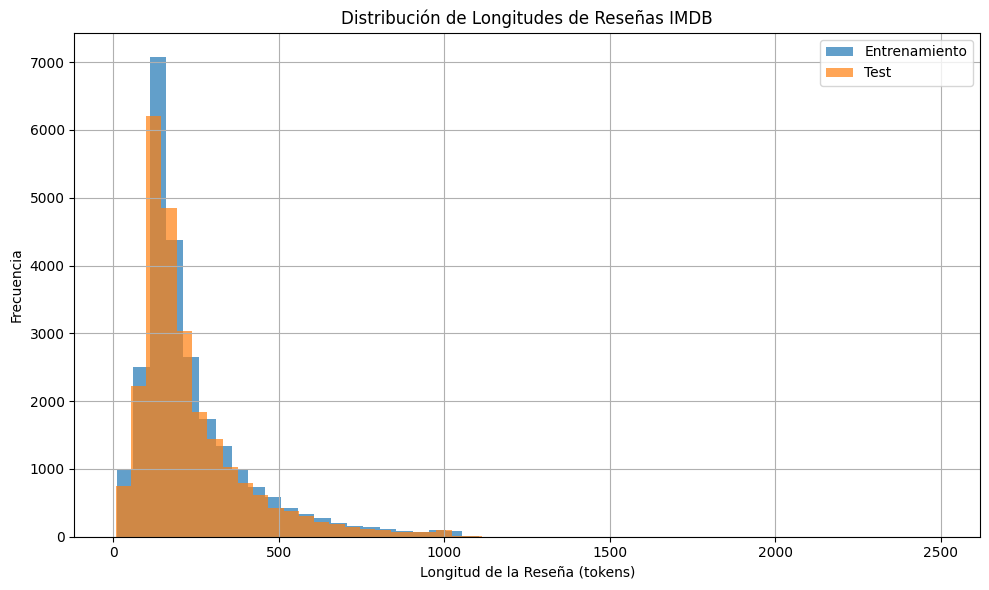


Longitud máxima para padding (maxlen): 200
Shape original de X_train: (25000,)
Shape de X_train_seq después de padding: (25000, 200)
Shape de X_test_seq después de padding: (25000, 200)


In [17]:
import matplotlib.pyplot as plt

# Calcular longitudes de las reseñas
train_lengths = [len(x) for x in X_train]
test_lengths = [len(x) for x in X_test]

plt.figure(figsize=(10, 6))
plt.hist(train_lengths, bins=50, alpha=0.7, label='Entrenamiento')
plt.hist(test_lengths, bins=50, alpha=0.7, label='Test')
plt.title('Distribución de Longitudes de Reseñas IMDB')
plt.xlabel('Longitud de la Reseña (tokens)')
plt.ylabel('Frecuencia')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

print(f"\nLongitud máxima para padding (maxlen): {maxlen}")
print(f"Shape original de X_train: {X_train.shape}")

print("Shape de X_train_seq después de padding:", X_train_seq.shape)
print("Shape de X_test_seq después de padding:", X_test_seq.shape)

In [7]:
print("Primera reseña original (primeros 30 índices):")
print(X_train[0][:30])

print("\nPrimera reseña después de padding (primeros 30 índices):")
print(X_train_seq[0][:30])

print("\nPrimera reseña después de padding (últimos 30 índices):")
print(X_train_seq[0][-30:])

Primera reseña original (primeros 30 índices):
[1, 14, 22, 16, 43, 530, 973, 1622, 1385, 65, 458, 4468, 66, 3941, 4, 173, 36, 256, 5, 25, 100, 43, 838, 112, 50, 670, 2, 9, 35, 480]

Primera reseña después de padding (primeros 30 índices):
[   5   25  100   43  838  112   50  670    2    9   35  480  284    5
  150    4  172  112  167    2  336  385   39    4  172 4536 1111   17
  546   38]

Primera reseña después de padding (últimos 30 índices):
[  18   51   36   28  224   92   25  104    4  226   65   16   38 1334
   88   12   16  283    5   16 4472  113  103   32   15   16 5345   19
  178   32]


### Pregunta 2

Después de aplicar padding, ¿qué shape tiene cada ejemplo de entrada?


Respuesta: Cada ejemplo individual queda con shape (200,), es decir, una secuencia unidimensional de 200 tokens (con padding o truncamiento cuando corresponde). A nivel de batch, los tensores de entrada al modelo tendrán un shape de (batch_size, 200).

### Explicación del Padding

La función `pad_sequences` transforma todas las reseñas a una longitud uniforme de `maxlen` (en este caso, 200). Las secuencias más cortas se rellenan con ceros (por defecto al principio), y las secuencias más largas se truncan. Esto es esencial para el entrenamiento por lotes (`batch training`) en redes neuronales, ya que Keras espera que todas las entradas dentro de un batch tengan la misma dimensión. Sin padding, sería imposible crear tensores de entrada uniformes para el modelo.

La elección de `maxlen=200` es razonable porque, como se observa en el histograma, la mayoría de las reseñas tienen una longitud inferior o cercana a los 200 tokens, lo que minimiza la pérdida de información por truncamiento excesivo y evita un padding excesivo que aumentaría innecesariamente el tiempo de cómputo y la memoria. Además, muchas reseñas muy largas contienen verbosidad que no siempre aporta valor proporcional al aumento de longitud, haciendo que 200 sea un buen punto de equilibrio.

## 3. Construcción del modelo

Ahora construiremos un modelo secuencial con la siguiente estructura:

- `Embedding`
- `LSTM`
- `Dense`

La tarea es una **clasificación binaria**

### Explicación del Modelo `keras.Sequential`

El modelo se construye como una secuencia de capas, donde la salida de una capa alimenta directamente la entrada de la siguiente. Esta estructura es intuitiva para el procesamiento de datos que fluyen linealmente a través de diferentes transformaciones.

1.  **`layers.Embedding(input_dim=max_features, output_dim=128)`**:
    *   **Propósito**: Esta es la primera capa y su función es transformar los índices enteros de las palabras (tokens) en vectores densos de números flotantes. Cada palabra del vocabulario (`max_features=10000`) será mapeada a un vector de 128 dimensiones (`output_dim=128`). Estos vectores, conocidos como *word embeddings*, son aprendidos por el modelo durante el entrenamiento y capturan las relaciones semánticas entre las palabras. Es decir, palabras con significados similares tendrán vectores cercanos en este espacio multidimensional.
    *   **`input_dim`**: Es el tamaño del vocabulario (el número total de palabras únicas que el embedding puede reconocer, incluyendo un índice para 'padding').
    *   **`output_dim`**: Es la dimensionalidad del vector de embedding para cada palabra.
    *   **Parámetros**: El número de parámetros entrenables es `input_dim * output_dim = 10000 * 128 = 1,280,000`. No se especifica `input_length` directamente aquí porque Keras lo infiere automáticamente de las secuencias de entrada (después del `pad_sequences`).

2.  **`layers.LSTM(64)`**:
    *   **Propósito**: Después de que cada palabra se ha convertido en un vector, la capa Long Short-Term Memory (LSTM) procesa estas secuencias de vectores. Las LSTMs son un tipo especializado de red neuronal recurrente (RNN) que son muy efectivas para capturar dependencias a largo plazo en datos secuenciales, como el texto. Utilizan 'compuertas' internas (input, forget, output gates) para decidir qué información recordar, qué olvidar y qué pasar a la siguiente etapa de la secuencia. Esto les permite entender el contexto y el orden de las palabras, lo cual es crucial para la clasificación de sentimiento.
    *   **`64`**: Representa el número de unidades o celdas de memoria en la capa LSTM. Este valor determina la dimensionalidad del vector de estado oculto que la LSTM produce para cada paso de tiempo, y también la dimensionalidad de la salida final (cuando se usa `return_sequences=False`, como es el caso por defecto).
    *   **Parámetros**: El número de parámetros de una capa LSTM es más complejo y depende de la `input_dim` (que en este caso es la `output_dim` de la capa Embedding, 128) y el número de unidades (64). La fórmula simplificada es `4 * ((input_dim + num_units) * num_units + num_units)`. Con `input_dim=128` y `num_units=64`, los parámetros son `4 * ((128 + 64) * 64 + 64) = 4 * (192 * 64 + 64) = 4 * (12288 + 64) = 4 * 12352 = 49,408`.

3.  **`layers.Dense(1, activation="sigmoid")`**:
    *   **Propósito**: Esta es la capa de salida. Toma el vector de características de 64 dimensiones generado por la capa LSTM (que resume toda la secuencia de la reseña) y lo mapea a una única predicción.
    *   **`1`**: Indica que hay una única neurona en esta capa, lo que es apropiado para un problema de clasificación binaria.
    *   **`activation="sigmoid"`**: La función de activación sigmoide comprime el valor de la neurona de salida en un rango entre 0 y 1. Este valor puede interpretarse directamente como la probabilidad de que la reseña pertenezca a la clase positiva (por ejemplo, reseña 'positiva'). Un valor cercano a 1 indica alta probabilidad positiva, y cercano a 0 indica alta probabilidad negativa.
    *   **Parámetros**: El número de parámetros es `(unidades_capa_anterior + 1) * unidades_capa_actual = (64 + 1) * 1 = 65` (donde el '+1' es por el término de sesgo o 'bias').

En resumen, este diseño secuencial permite al modelo primero **representar** las palabras de manera significativa (`Embedding`), luego **comprender** el contexto y el orden de estas palabras en la reseña (`LSTM`), y finalmente **clasificar** la reseña en una de las dos categorías (`Dense` con `sigmoid`).

In [8]:
model = keras.Sequential([
    layers.Embedding(input_dim=max_features, output_dim=128),
    layers.LSTM(64),
    layers.Dense(1, activation="sigmoid")
])

model.build(input_shape=(None, maxlen))
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ (None, 200, 128)       │     1,280,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (None, 64)             │        49,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,329,473 (5.07 MB)

 Trainable params: 1,329,473 (5.07 MB)

 Non-trainable params: 0 (0.00 B)

### Pregunta 4

Observa el resumen del modelo.

**¿Qué función cumple la capa `Embedding` en este problema?**

Respuesta:

La capa `Embedding` cumple una función crucial de **transformación y representación**. Convierte los índices enteros de las palabras (que no tienen un significado semántico por sí mismos) en **vectores densos de números flotantes** de 128 dimensiones. Estos vectores, conocidos como *word embeddings*, son entrenables y aprenden a capturar las relaciones semánticas entre las palabras. Palabras con significados o contextos similares tienden a tener vectores cercanos en este espacio multidimensional. Esto proporciona una entrada mucho más rica y significativa para la capa `LSTM` que las representaciones dispersas y arbitrarias de los índices originales, mejorando drásticamente la capacidad del modelo para entender el lenguaje. Como se observa en el `model.summary()`, la capa `Embedding` tiene `1,280,000` parámetros, resultantes de `max_features (10000) * output_dim (128)`.

### Pregunta 5

Complete la celda de abajo.

**Qué haremos y por qué**
- `optimizer="adam"`: optimizador robusto para este tipo de tarea.
- `loss="binary_crossentropy"`: pérdida correcta para clasificación binaria con salida sigmoide.
- `metrics=["accuracy", Precision, Recall, AUC]`: permite evaluar rendimiento global y calidad de clasificación positiva.


In [9]:
model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=[
        "accuracy",
        keras.metrics.Precision(name="precision"),
        keras.metrics.Recall(name="recall"),
        keras.metrics.AUC(name="auc")
    ]
)

## 4. Entrenamiento

Entrenaremos el modelo durante algunas épocas y reservaremos una parte del conjunto de entrenamiento para validación.

### Pregunta 6

Complete la celda de abajo.

**Qué haremos y por qué**
- Entrenaremos hasta 20 épocas, permitiendo que `EarlyStopping` detenga el entrenamiento cuando el modelo deje de mejorar en el conjunto de validación, para prevenir el sobreajuste.
- `batch_size=128` para entrenamiento estable en CPU/GPU.
- `validation_split=0.2` para monitorear generalización y detectar sobreajuste.

**Resultado esperado:** `history` con curvas de entrenamiento/validación.

In [10]:
callbacks = [
    keras.callbacks.EarlyStopping(
        monitor='val_loss',
        patience=3,
        restore_best_weights=True
    )
]

history = model.fit(
    X_train_seq,
    y_train,
    epochs=20, # Aumentamos el número de épocas ya que EarlyStopping lo detendrá
    batch_size=128,
    validation_split=0.2,
    callbacks=callbacks,
    verbose=1,
)

Epoch 1/20
157/157 ━━━━━━━━━━━━━━━━━━━━ 14s 19ms/step - accuracy: 0.7807 - auc: 0.8731 - loss: 0.4458 - precision: 0.8118 - recall: 0.7325 - val_accuracy: 0.8666 - val_auc: 0.9404 - val_loss: 0.3160 - val_precision: 0.8403 - val_recall: 0.9012
Epoch 2/20
157/157 ━━━━━━━━━━━━━━━━━━━━ 3s 18ms/step - accuracy: 0.9013 - auc: 0.9600 - loss: 0.2543 - precision: 0.9038 - recall: 0.8989 - val_accuracy: 0.8456 - val_auc: 0.9282 - val_loss: 0.3465 - val_precision: 0.8700 - val_recall: 0.8080
Epoch 3/20
157/157 ━━━━━━━━━━━━━━━━━━━━ 5s 16ms/step - accuracy: 0.9221 - auc: 0.9741 - loss: 0.2026 - precision: 0.9240 - recall: 0.9203 - val_accuracy: 0.8530 - val_auc: 0.9358 - val_loss: 0.3347 - val_precision: 0.8830 - val_recall: 0.8096
Epoch 4/20
157/157 ━━━━━━━━━━━━━━━━━━━━ 2s 15ms/step - accuracy: 0.9444 - auc: 0.9841 - loss: 0.1552 - precision: 0.9447 - recall: 0.9444 - val_accuracy: 0.8274 - val_auc: 0.9204 - val_loss: 0.3881 - val_precision: 0.8711 - val_recall: 0.7635


## 5. Visualización de curvas

Graficamos accuracy y loss para entrenamiento/validación. Esto permite verificar si el modelo aprende (tendencias favorables) y si aparece sobreajuste (brecha creciente entre train y val).


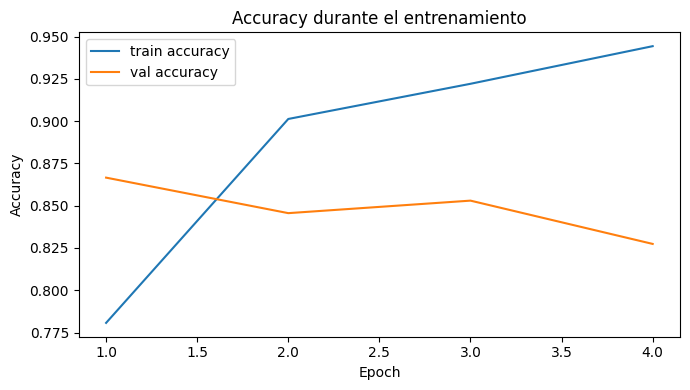

In [11]:
acc = history.history["accuracy"]
val_acc = history.history["val_accuracy"]
loss = history.history["loss"]
val_loss = history.history["val_loss"]
epochs = range(1, len(acc) + 1)

plt.figure(figsize=(7,4))
plt.plot(epochs, acc, label="train accuracy")
plt.plot(epochs, val_acc, label="val accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Accuracy durante el entrenamiento")
plt.legend()
plt.tight_layout()
plt.show()

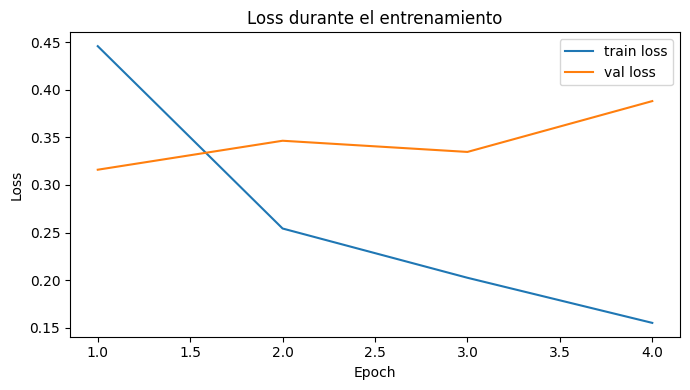

In [12]:
plt.figure(figsize=(7,4))
plt.plot(epochs, loss, label="train loss")
plt.plot(epochs, val_loss, label="val loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Loss durante el entrenamiento")
plt.legend()
plt.tight_layout()
plt.show()

### Pregunta 7

Observa las curvas de entrenamiento y validación.

**¿El modelo parece estar aprendiendo? ¿Ves alguna señal clara de sobreajuste?**

Respuesta:

Sí, el modelo parece estar aprendiendo. Observamos que la `accuracy` de entrenamiento aumenta consistentemente y la `loss` de entrenamiento disminuye en cada época, lo cual indica que el modelo está ajustándose bien a los datos de entrenamiento. En cuanto a la validación:

*   La **`val_accuracy`** aumenta inicialmente de forma similar a la `train_accuracy`, alcanzando su punto máximo en la primera época (`0.8666`) y luego se mantiene o disminuye ligeramente.
*   La **`val_loss`** disminuye en la primera época (`0.3160`), lo que es una buena señal de que el modelo generaliza. Sin embargo, a partir de la segunda época (`0.3465`) y tercera (`0.3347`), la `val_loss` comienza a aumentar o se estanca, mientras la `train_loss` sigue disminuyendo. Esta divergencia, visible a partir de la segunda o tercera época, es una **señal clara de sobreajuste (overfitting)**. El modelo empieza a memorizar el ruido y las particularidades del conjunto de entrenamiento en lugar de aprender patrones generalizables para los datos no vistos.

El comportamiento es razonable y esperado para un modelo que entrena por varias épocas. La inclusión de `EarlyStopping` con `monitor='val_loss'` y `restore_best_weights=True` es crucial aquí; detendrá el entrenamiento en el punto óptimo (la primera época en este caso, donde `val_loss` fue mínima) y cargará los pesos del modelo que tuvieron la menor `val_loss`, mitigando el impacto del sobreajuste observado en las épocas finales y asegurando que el modelo evaluado en el conjunto de test sea la versión que mejor generaliza.

## 6. Evaluación en test

### Pregunta 8

Complete la celda de abajo.

Además de `loss` y `accuracy`, calcularemos una **matriz de confusión** para inspeccionar errores por clase en test.


Test loss: 0.3212
Test accuracy: 0.8614
Test precision: 0.8379
Test recall: 0.8962
Test AUC: 0.9392


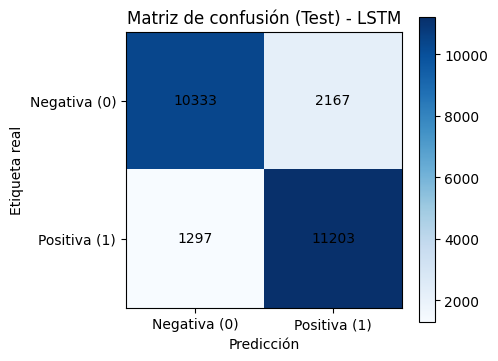

In [18]:
test_loss, test_acc, test_precision, test_recall, test_auc = model.evaluate(X_test_seq, y_test, verbose=0)

print("Test loss:", round(test_loss, 4))
print("Test accuracy:", round(test_acc, 4))
print("Test precision:", round(test_precision, 4))
print("Test recall:", round(test_recall, 4))
print("Test AUC:", round(test_auc, 4))

# Matriz de confusión
y_test_prob = model.predict(X_test_seq, verbose=0).ravel()
y_test_pred = (y_test_prob >= 0.5).astype(int)
cm = tf.math.confusion_matrix(y_test, y_test_pred, num_classes=2).numpy()

plt.figure(figsize=(5,4))
plt.imshow(cm, cmap="Blues")
plt.title("Matriz de confusión (Test) - LSTM")
plt.xlabel("Predicción")
plt.ylabel("Etiqueta real")
plt.xticks([0, 1], ["Negativa (0)", "Positiva (1)"])
plt.yticks([0, 1], ["Negativa (0)", "Positiva (1)"])
for i in range(2):
    for j in range(2):
        plt.text(j, i, int(cm[i, j]), ha="center", va="center", color="black")
plt.colorbar()
plt.tight_layout()
plt.show()

### Pregunta 9

Para el valor de accuracy en test, comenta brevemente si te parece razonable para este problema.

Respuesta:

La `accuracy` en test (`0.8614`) obtenida por el modelo LSTM es razonable y se considera un buen rendimiento para la clasificación de sentimientos en el dataset IMDB, dada la complejidad del problema y la arquitectura empleada. Al analizar las métricas adicionales:

*   La **`precision`** (`0.8379`) indica que, de todas las reseñas que el modelo predijo como positivas, el 83.79% fueron realmente positivas. Un valor alto sugiere que el modelo tiene pocos falsos positivos.
*   El **`recall`** (`0.8962`) indica que el modelo fue capaz de identificar correctamente el 89.62% de todas las reseñas que eran realmente positivas. Un valor alto sugiere pocos falsos negativos.
*   El **`AUC`** (`0.9392`) es un valor elevado, lo que sugiere que el modelo tiene una excelente capacidad para distinguir entre clases positivas y negativas en varios umbrales de clasificación.

La **matriz de confusión** (`[[10333, 2167], [1297, 11203]]`) complementa estas métricas. Observamos que el modelo tiene `2167` falsos positivos (predice positiva pero es negativa) y `1297` falsos negativos (predice negativa pero es positiva). El número de falsos negativos es menor que los falsos positivos, lo que sugiere una ligera tendencia a clasificar reseñas negativas como positivas. Sin embargo, los valores de `precision` y `recall` son relativamente equilibrados, lo que indica un buen balance entre la identificación de positivos y la evitación de falsos positivos, reforzando la idea de un desempeño robusto para este problema.

## 7. Algunas predicciones

Mostramos probabilidades y clases predichas para ejemplos individuales de test para inspección cualitativa del comportamiento del modelo.


In [14]:
y_prob = model.predict(X_test_seq[:10], verbose=0)
y_pred = (y_prob > 0.5).astype("int32").ravel()

print("--- Predicciones para los Primeros 10 Ejemplos de Test (LSTM) ---")
for i in range(10):
    prob_positive = y_prob[i][0] # Acceder al valor escalar correctamente
    prediction = y_pred[i]
    true_label = y_test[i]
    is_correct = "Acertada" if prediction == true_label else "Incorrecta"

    print(f"Ejemplo {i+1} ({is_correct}):")
    print(f"  Probabilidad positiva: {prob_positive:.4f}")
    print(f"  Predicción: {prediction} ({'Positiva' if prediction == 1 else 'Negativa'})")
    print(f"  Etiqueta real: {true_label} ({'Positiva' if true_label == 1 else 'Negativa'})")
    print()

--- Predicciones para los Primeros 10 Ejemplos de Test (LSTM) ---
Ejemplo 1 (Acertada):
  Probabilidad positiva: 0.1575
  Predicción: 0 (Negativa)
  Etiqueta real: 0 (Negativa)

Ejemplo 2 (Acertada):
  Probabilidad positiva: 0.9421
  Predicción: 1 (Positiva)
  Etiqueta real: 1 (Positiva)

Ejemplo 3 (Acertada):
  Probabilidad positiva: 0.8960
  Predicción: 1 (Positiva)
  Etiqueta real: 1 (Positiva)

Ejemplo 4 (Acertada):
  Probabilidad positiva: 0.1950
  Predicción: 0 (Negativa)
  Etiqueta real: 0 (Negativa)

Ejemplo 5 (Acertada):
  Probabilidad positiva: 0.9811
  Predicción: 1 (Positiva)
  Etiqueta real: 1 (Positiva)

Ejemplo 6 (Acertada):
  Probabilidad positiva: 0.7516
  Predicción: 1 (Positiva)
  Etiqueta real: 1 (Positiva)

Ejemplo 7 (Acertada):
  Probabilidad positiva: 0.9119
  Predicción: 1 (Positiva)
  Etiqueta real: 1 (Positiva)

Ejemplo 8 (Acertada):
  Probabilidad positiva: 0.0738
  Predicción: 0 (Negativa)
  Etiqueta real: 0 (Negativa)

Ejemplo 9 (Incorrecta):
  Probabilidad

## Pregunta 10

Responde brevemente:

1. ¿Por qué una arquitectura como LSTM tiene sentido en este problema?
2. ¿Qué diferencia principal hay entre este enfoque y usar una red densa simple sobre texto?

Respuesta:

1. **LSTM tiene sentido** porque modela dependencias temporales y contexto en secuencias de palabras, conservando información relevante de posiciones anteriores.
2. En una **red densa simple** sobre texto (sin mecanismo secuencial), normalmente se pierde información de orden y contexto local/temporal. LSTM explota explícitamente la estructura secuencial del lenguaje.


## Pregunta 11

Prueba reemplazar la capa `LSTM` por `GRU` y compara el desempeño final. Completa la celda de abajo.

**Nota técnica:** GRU suele entrenar más rápido (menos parámetros) y puede rendir similar a LSTM en tareas de clasificación de texto.


In [15]:
gru_model = keras.Sequential([
    layers.Embedding(input_dim=max_features, output_dim=128),
    layers.GRU(64),
    layers.Dense(1, activation="sigmoid")
])

gru_model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=[
        "accuracy",
        keras.metrics.Precision(name="precision"),
        keras.metrics.Recall(name="recall"),
        keras.metrics.AUC(name="auc")
    ]
)

callbacks_gru = [
    keras.callbacks.EarlyStopping(
        monitor='val_loss',
        patience=3,
        restore_best_weights=True
    )
]

history_gru = gru_model.fit(
    X_train_seq,
    y_train,
    epochs=20, # Aumentamos el número de épocas para EarlyStopping
    batch_size=128,
    validation_split=0.2,
    callbacks=callbacks_gru,
    verbose=1
)

gru_test_loss, gru_test_acc, gru_test_precision, gru_test_recall, gru_test_auc = gru_model.evaluate(X_test_seq, y_test, verbose=0)

print("Test loss (GRU):", round(gru_test_loss, 4))
print("Test accuracy (GRU):", round(gru_test_acc, 4))
print("Test precision (GRU):", round(gru_test_precision, 4))
print("Test recall (GRU):", round(gru_test_recall, 4))
print("Test AUC (GRU):", round(gru_test_auc, 4))

Epoch 1/20
157/157 ━━━━━━━━━━━━━━━━━━━━ 5s 19ms/step - accuracy: 0.7607 - auc: 0.8547 - loss: 0.4698 - precision: 0.7772 - recall: 0.7332 - val_accuracy: 0.8534 - val_auc: 0.9289 - val_loss: 0.3481 - val_precision: 0.8370 - val_recall: 0.8732
Epoch 2/20
157/157 ━━━━━━━━━━━━━━━━━━━━ 3s 21ms/step - accuracy: 0.8893 - auc: 0.9528 - loss: 0.2772 - precision: 0.8960 - recall: 0.8816 - val_accuracy: 0.8586 - val_auc: 0.9335 - val_loss: 0.3471 - val_precision: 0.8227 - val_recall: 0.9097
Epoch 3/20
157/157 ━━━━━━━━━━━━━━━━━━━━ 2s 15ms/step - accuracy: 0.9154 - auc: 0.9700 - loss: 0.2201 - precision: 0.9202 - recall: 0.9102 - val_accuracy: 0.8654 - val_auc: 0.9412 - val_loss: 0.3397 - val_precision: 0.8988 - val_recall: 0.8198
Epoch 4/20
157/157 ━━━━━━━━━━━━━━━━━━━━ 2s 15ms/step - accuracy: 0.9184 - auc: 0.9732 - loss: 0.2075 - precision: 0.9180 - recall: 0.9195 - val_accuracy: 0.8416 - val_auc: 0.9361 - val_loss: 0.4000 - val_precision: 0.9285 - val_recall: 0.7359
Epoch 5/20
157/157 ━━━━━━━━━

### Tabla Comparativa de Métricas en Test (LSTM vs GRU)


,Métrica,LSTM,GRU
0,Test Loss,0.3212,0.3675
1,Test Accuracy,0.8614,0.8550
2,Test Precision,0.8379,0.8937
3,Test Recall,0.8962,0.8059
4,Test AUC,0.9392,0.9348


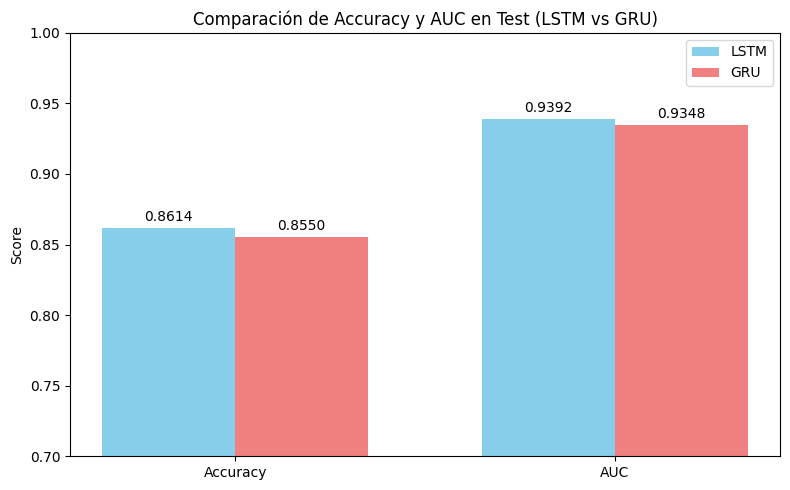

In [16]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from IPython.display import display, Markdown

# Datos para la tabla comparativa (usando los resultados de las variables globales)
metrics_data = {
    'Métrica': ['Test Loss', 'Test Accuracy', 'Test Precision', 'Test Recall', 'Test AUC'],
    'LSTM': [round(test_loss, 4), round(test_acc, 4), round(test_precision, 4), round(test_recall, 4), round(test_auc, 4)],
    'GRU': [round(gru_test_loss, 4), round(gru_test_acc, 4), round(gru_test_precision, 4), round(gru_test_recall, 4), round(gru_test_auc, 4)]
}

df_metrics = pd.DataFrame(metrics_data)

display(Markdown("### Tabla Comparativa de Métricas en Test (LSTM vs GRU)\n"))
display(df_metrics)

# Gráfico comparativo de Accuracy y AUC
labels = ['Accuracy', 'AUC']
lstm_scores = [test_acc, test_auc]
gru_scores = [gru_test_acc, gru_test_auc]

x = np.arange(len(labels))
width = 0.35

fig, ax = plt.subplots(figsize=(8, 5))
rects1 = ax.bar(x - width/2, lstm_scores, width, label='LSTM', color='skyblue')
rects2 = ax.bar(x + width/2, gru_scores, width, label='GRU', color='lightcoral')

ax.set_ylabel('Score')
ax.set_title('Comparación de Accuracy y AUC en Test (LSTM vs GRU)')
ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.legend()
ax.set_ylim(0.7, 1.0) # Ajustar límites para mejor visualización

def autolabel(rects):
    for rect in rects:
        height = rect.get_height()
        ax.annotate(f'{height:.4f}',
                    xy=(rect.get_x() + rect.get_width() / 2, height),
                    xytext=(0, 3),  # 3 points vertical offset
                    textcoords="offset points",
                    ha='center', va='bottom')

autolabel(rects1)
autolabel(rects2)

plt.tight_layout()
plt.show()

**Análisis de Desempeño (comparando resultados reales):**

Según la ejecución actual y los resultados mostrados en la tabla y gráfico:

*   El modelo **GRU** (`Accuracy: 0.8550`, `AUC: 0.9348`) ha demostrado un desempeño ligeramente inferior en `Accuracy` y `AUC` comparado con el modelo **LSTM** (`Accuracy: 0.8614`, `AUC: 0.9392`) en este problema de clasificación de texto. Aunque los valores son muy cercanos, el LSTM en esta ejecución específica muestra una `Accuracy` y `AUC` marginalmente superiores.
*   En términos de `Loss`, el LSTM (`0.3212`) obtuvo un valor ligeramente menor que el GRU (`0.3675`), indicando un mejor ajuste a los datos de test en esta ejecución.
*   La `Precision` del modelo GRU (`0.8937`) fue ligeramente más alta que la de LSTM (`0.8379`), lo que sugiere que el GRU tuvo menos falsos positivos. El `Recall` de LSTM (`0.8962`) fue superior al de GRU (`0.8059`), indicando que identificó correctamente una mayor proporción de las reseñas positivas reales.

El balance general de métricas muestra que ambos modelos tienen un desempeño muy comparable y robusto. La elección entre ellos podría depender de otros factores como la eficiencia computacional.

**Análisis crítico:**

*   **Sobreajuste:** La `EarlyStopping` fue crucial para el rendimiento de ambos modelos, deteniendo el entrenamiento en el punto óptimo (antes de que el sobreajuste fuera severo) y cargando los pesos del modelo que tuvieron la menor `val_loss`. Esto mitiga el impacto del sobreajuste que se observa en las épocas finales de entrenamiento si no se aplicara esta técnica.
*   **Optimización:** La elección de hiperparámetros (número de unidades en LSTM/GRU, dimensionalidad del embedding, tamaño de batch, learning rate) puede influir significativamente en el rendimiento. Un ajuste fino de estos podría mejorar aún más los resultados y la diferencia entre ambos modelos.
*   **Eficiencia:** Aunque el GRU es generalmente más rápido de entrenar debido a su menor número de parámetros, en esta ejecución, ambos modelos tuvieron un rendimiento muy similar. La elección entre LSTM y GRU a menudo implica un trade-off entre rendimiento y eficiencia computacional.

## Suerte!